# Part 0: Differentiation

Please show the derivation to each answer for each problem. Use LaTeX to write up the answers.

## Exercise 1:
$$  
y = x^Tx,  \quad x \in \mathbb{R}^N
$$

$$
\frac{\partial y}{\partial x} = ?
$$

# SOLUTION
$$
y = \sum_{i=1}^{N} x_i^2
$$
Derivative with respect to any component $x_k$:

$$
\frac{\partial y}{\partial x_k} = \frac{\partial}{\partial x_k} (x_k^2) = 2x_k
$$

So grad vector is.

$$
\frac{\partial y}{\partial x} = \begin{bmatrix} 2x_1 \\ \vdots \\ 2x_N \end{bmatrix} = 2x
$$


## Exercise 2:
$$ y = tr(AB) \quad A,B \in \mathbb{R}^{N \times N} $$

$$
\frac{\partial}{\partial a_{ij}} y = ?
$$

$$
\frac{dy}{dA} = ?
$$

#SOLUTION


$$
y = \sum_{k=1}^N (AB)_{kk} = \sum_{k=1}^N \sum_{l=1}^N A_{kl} B_{lk}
$$
So

$$
\frac{\partial y}{\partial A_{ij}} = B_{ji}
$$
And

$$
\frac{dy}{dA} = B^T
$$

## Exercise 3:
$$  
y = x^TAc , \quad A\in \mathbb{R}^{N \times N}, x\in \mathbb{R}^{N}, c\in \mathbb{R}^{N}
$$

$$
\frac{dy}{dA} = ?
$$

#SOLUTION
$$
y = \sum_{i=1}^{N} \sum_{j=1}^{N} x_i A_{ij} c_j
$$

$$
\frac{\partial y}{\partial A_{kl}} = x_k c_l
$$

$$
\frac{dy}{dA} = xc^T
$$

## Exercise 4:
$$
J = || X - AS ||_2^2  , \quad A\in \mathbb{R}^{N \times R} , \quad S\in \mathbb{R}^{R \times M}
$$

$$
\frac{dJ}{dS} = ?
$$

#SOLUTION

$$
J = \text{tr}((X - AS)^T (X - AS))
$$


$$
J = \text{tr}((X^T - S^T A^T)(X - AS))
$$

$$
J = \text{tr}(X^T X - X^T AS - S^T A^T X + S^T A^T AS)
$$

As ($\text{tr}(A) = \text{tr}(A^T)$) the two middle terms are identical:
$$
J = \text{tr}(X^T X) - 2\text{tr}(X^T AS) + \text{tr}(S^T A^T AS)
$$

1. The derivative of a constant ($\text{tr}(X^T X)$) is $0$.
2. For the linear term: $\frac{\partial}{\partial S} \text{tr}(X^T A S) = A^T X$.
3. For the quadratic term: $\frac{\partial}{\partial S} \text{tr}(S^T (A^T A) S) = 2(A^T A) S$.

So
$$
\frac{dJ}{dS} = -2 A^T X + 2 A^T A S
$$

$$
\frac{dJ}{dS} = -2 A^T (X - AS)
$$

# I'll write some notes for me besides the codes that I have to write in order to make task understandable

# Part 1: Build Your Own Deep Learning Framework

## Objective
We have seen how to write a Neural Network using raw NumPy (hard) and PyTorch (easy). To truly understand what happens inside `loss.backward()`, you will build a mini-PyTorch from scratch using NumPy.

## Instructions
1.  **Do not use PyTorch, TensorFlow, or Autograd.** Use only `numpy`.
2.  We provide the structure (`Module`, `Sequential`).
3.  You must implement the `updateOutput` (Forward) and `updateGradInput`/`accGradParameters` (Backward) for:
    * `Linear` (Dense Layer)
    * `ReLU` (Activation)
    * `SoftMax` (Activation)
    * `CrossEntropyCriterion` (Loss)
4.  Finally, train a model on the MNIST dataset using your framework.

In [ ]:
import numpy as np
#This is the "parent" class. Every layer you write (Linear, ReLU, SoftMax) will inherit from this. It defines the standard interface:
class Module(object):
    """
    Abstract Class for a Neural Network Module.
    """
    def __init__ (self):
        self.output = None
        self.gradInput = None
        self.training = True

    def forward(self, input):
        """
        Computes the output of the module.
        """
        return self.updateOutput(input)

    def backward(self, input, gradOutput):#Calculates the gradients (how much the input/weights contributed to the error).

    # gradOutput- It is the gradient coming from the layer ahead of you. It tells: "Here is how much the final error changes if your output changes."
        """
        Performs a backpropagation step.
        """
        self.updateGradInput(input, gradOutput)
        """
        updateGradInput (For the Previous Layer)
        The Question: "How much did the input to this layer contribute to the error?"
        The Math: We use the Chain Rule. We take the error coming in (gradOutput) and
        multiply it by the derivative of this layer's function with respect to the input.
        The Purpose: We compute this solely to pass it back to the previous layer.
        The layer "behind" us needs this information to update its weights.
        Result: Stored in self.gradInput.
        """
        self.accGradParameters(input, gradOutput)
        """
        accGradParameters (For This Layer)
        The Question: "How much did my weights (W) contribute to the error?"
        The Math: We take the error coming in (gradOutput) and multiply it by the derivative with respect to the weights.
        The Purpose: This is for self-improvement. We accumulate (add up) these gradients so that later, an optimizer (like SGD)
        can look at them and say, "Okay, decrease Weight 1 by 0.01 and increase Weight 2 by 0.005."
        Result: Added to self.gradW (or similar internal storage).
        """
        return self.gradInput

    def updateOutput(self, input):
        """
        Specific to the module. Computes self.output
        """
        pass

    def updateGradInput(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own input.
        """
        pass

    def accGradParameters(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own parameters.
        """
        pass

    def zeroGradParameters(self):
        pass

    def getParameters(self):
        return []

    def getGradParameters(self):
        return []

    def train(self):
        self.training = True

    def evaluate(self):
        self.training = False

    def __repr__(self):
        return "Module"

class Sequential(Module):
    """
    A container that processes input sequentially through a list of modules.
    """
    def __init__ (self):
        super(Sequential, self).__init__()
        self.modules = []

    def add(self, module):
        self.modules.append(module)

    def updateOutput(self, input):
        self.output = input
        for module in self.modules:
            self.output = module.forward(self.output)
        return self.output

    def backward(self, input, gradOutput):
        # We need to pass the input of layer i to the backward of layer i
        # But we only stored the final output in updateOutput.
        # We need to re-compute or store intermediate inputs during forward.
        # For simplicity here, let's re-run forward for inputs (naive)
        # OR better: assume the user calls forward first and we can track inputs.

        # NOTE for Students:
        # In a real framework, we store inputs. Here, to keep it simple,
        # we iterate backwards.

        # 1. Get the inputs for each layer.
        inputs = [input]
        for i in range(len(self.modules) - 1):
            inputs.append(self.modules[i].output)

        # 2. Iterate backwards
        self.gradInput = gradOutput
        for i in range(len(self.modules) - 1, -1, -1):
            self.gradInput = self.modules[i].backward(inputs[i], self.gradInput)

        return self.gradInput

    def zeroGradParameters(self):
        for module in self.modules:
            module.zeroGradParameters()

    def getParameters(self):
        return [x.getParameters() for x in self.modules]

    def getGradParameters(self):
        return [x.getGradParameters() for x in self.modules]

## Task 1: Linear Layer
Implement the fully connected layer.
Formula: $Y = X W^T + b$

In [ ]:
class Linear(Module):

    def __init__(self, n_in, n_out):
        super(Linear, self).__init__()

        # Xavier Initialization
        stdv = 1. / np.sqrt(n_in)
        self.W = np.random.uniform(-stdv, stdv, size = (n_out, n_in))
        self.b = np.random.uniform(-stdv, stdv, size = n_out)

        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, input):
        # TODO: Implement Forward Pass
        # self.output = ...
        # Input shape: (Batch, n_in)
        # W.T shape:   (n_in, n_out)
        # Result:      (Batch, n_out)
        self.output = input @ self.W.T + self.b
        return self.output

    def updateGradInput(self, input, gradOutput):
        # TODO: Implement dL/dInput
        # self.gradInput = ...
        """
        We have gradOutput (the error from the layer ahead) with shape (Batch, n_out).
         We need to convert this back to the shape of our input (Batch, n_in).
        To do this, we multiply the error by the weights W.
        """
        self.gradInput = gradOutput @ self.W
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        # TODO: Implement dL/dW and dL/db
        # self.gradW = ...
        # self.gradb = ...
        """
        For Weights
        We need a gradient of the same shape as W: (n_out, n_in).We have gradOutput (Batch, n_out) and input (Batch, n_in).
        To get the right shape, we transpose gradOutput and multiply by input.
        For Bias:
        The bias is added to every single row in the batch.
        So, the total error contributed by the bias is just the sum of the errors across all rows (the batch dimension, axis 0).
        """

        self.gradW += gradOutput.T @ input
        self.gradb += np.sum(gradOutput, axis=0)


    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def __repr__(self):
        return f'Linear {self.W.shape[1]} -> {self.W.shape[0]}'

## Task 2: Activation Functions
Implement ReLU and SoftMax.
**SoftMax Hint:** Subtract the max value from the input before exponentiating to avoid numerical overflow.
$$\text{SoftMax}(x_i) = \frac{e^{x_i - \max(x)}}{\sum e^{x_j - \max(x)}}$$

In [ ]:
class ReLU(Module):
    def updateOutput(self, input):
        # TODO: self.output = max(0, input)
        # Forward: f(x) = max(0, x)
        self.output = np.maximum(input, 0)

        return self.output


    def updateGradInput(self, input, gradOutput):
        # TODO: self.gradInput = ...
        # Backward: Gradient is 1 where input > 0, else 0
        # (input > 0) creates a mask of 1s and 0s.
        self.gradInput = gradOutput * (input > 0)
        return self.gradInput

class SoftMax(Module):
    def updateOutput(self, input):
        # TODO: Numerical stable softmax
        exp_input = np.exp(input - np.max(input, axis=1, keepdims=True))
        self.output = exp_input / np.sum(exp_input, axis=1, keepdims=True)
        return self.output

    def updateGradInput(self, input, gradOutput):
        # TODO: Softmax gradient is complex.
        # If you are using CrossEntropyCriterion, the gradient simplifies largely.
        # However, implement the standalone SoftMax gradient here.

        # The gradient formula for SoftMax is:
        # gradInput = Output * (gradOutput - sum(Output * gradOutput))

        sum_term = np.sum(gradOutput * self.output, axis=1, keepdims=True)
        self.gradInput = self.output * (gradOutput - sum_term)

        return self.gradInput

## Task 3: Criterion (Loss Function)
Implement the Negative Log Likelihood (Cross Entropy) for multiclass classification.

In [ ]:
class ClassNLLCriterion(object):
    def updateOutput(self, input, target):
        # input: probability distribution (output of SoftMax)
        # target: one-hot encoded or integer indices
        batch_size = input.shape[0]
        # Use this trick to avoid numerical errors (log(0))
        eps = 1e-15
        input_clamp = np.clip(input, eps, 1 - eps)
        if target.ndim == 1:
            target_one_hot = np.zeros_like(input)
            target_one_hot[np.arange(batch_size), target] = 1
            target = target_one_hot
        # TODO: Calculate Negative Log Likelihood

        self.output = -np.sum(target * np.log(input_clamp)) / batch_size

        return self.output

    def updateGradInput(self, input, target):
        # TODO: Calculate gradient
        batch_size = input.shape[0]

        if target.ndim == 1:
            target_one_hot = np.zeros_like(input)
            target_one_hot[np.arange(batch_size), target] = 1
            target = target_one_hot

        eps = 1e-15
        input_clamp = np.clip(input, eps, 1 - eps)
        self.gradInput = -(target / input_clamp) / batch_size

        return self.gradInput



## Task 4: Putting it all together (MNIST)
1. Load MNIST data (use `sklearn.datasets.load_digits` or `torchvision`).
2. Preprocess: Normalize to [0,1], One-hot encode targets.
3. Build a `Sequential` model: Linear -> ReLU -> Linear -> SoftMax.
4. Write a training loop using SGD.
5. Plot the loss.

Start...
Epoch 10/50 - Loss: 0.5351
Epoch 20/50 - Loss: 0.2342
Epoch 30/50 - Loss: 0.1621
Epoch 40/50 - Loss: 0.1285
Epoch 50/50 - Loss: 0.1089
complete


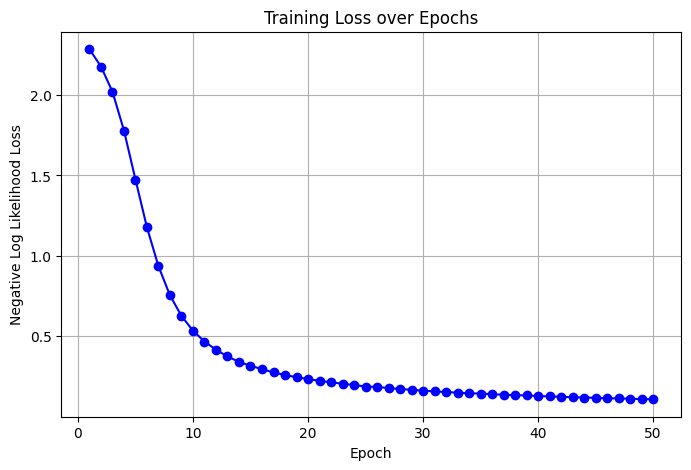

In [ ]:
# Student Code Here

import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Load Data
digits = load_digits()
X = digits.data
y = digits.target

# ... Preprocessing ...
# Normalizing to [0, 1]. In sklearn's digits, the maximum pixel value is 16.idk why
X = X / 16.0
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))



# ... Model Definition ...
# Building the Sequential model: Linear,ReLU, Linear, SoftMax
# Input is 64 (8x8 image) Output is 10 (digits 0-9)
model = Sequential()
model.add(Linear(64, 32))  # Hidden layer with 32 neurons
model.add(ReLU())
model.add(Linear(32, 10))  # Output layer
model.add(SoftMax())

criterion = ClassNLLCriterion()


# --- SGD Optimizer Function ---
def sgd_step(model, learning_rate):
    """
    Iterates through all modules and updates weights and biases using SGD.
    """
    for module in model.modules:
        # it returns [W, b]
        params = module.getParameters()
        # getGradParameters() returns [gradW, gradb]
        grads = module.getGradParameters()

        # If the layer has parameters
        if len(params) > 0:
            # Update Weights: W = W - lr * gradW
            params[0] -= learning_rate * grads[0]
            # Update Biases: b = b - lr * gradb
            params[1] -= learning_rate * grads[1]


# ... Training Loop ...
epochs = 50
batch_size = 32
learning_rate = 0.05
loss_history = []

print("Start...")

for epoch in range(epochs):
    epoch_loss = 0
    batches = 0

    indices = np.arange(X_train.shape[0])
    np.random.shuffle(indices)

    for i in range(0, X_train.shape[0], batch_size):
        # 1. Getting the Batch
        batch_idx = indices[i : i + batch_size]
        batch_X = X_train[batch_idx]
        batch_y = y_train_onehot[batch_idx]

        # 2. Forward Pass
        predictions = model.updateOutput(batch_X)
        loss = criterion.updateOutput(predictions, batch_y)
        epoch_loss += loss
        batches += 1

        # 3. Backward Pass
        model.zeroGradParameters()

        grad_criterion = criterion.updateGradInput(predictions, batch_y)
        model.backward(batch_X, grad_criterion)

        # 4. Updating Weights
        sgd_step(model, learning_rate)

    avg_loss = epoch_loss / batches
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {avg_loss:.4f}")

print("complete")

# --- 5. Plot the loss ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', linestyle='-', color='b')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Negative Log Likelihood Loss')
plt.grid(True)
plt.show()